In [1]:
import pyarrow.parquet as pq
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = pq.ParquetFile("C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\data\\uk_crime_full_cleaned.parquet")

print(data.schema)

required group field_id=-1 duckdb_schema {
  optional binary field_id=-1 Crime ID (String);
  optional binary field_id=-1 Month (String);
  optional binary field_id=-1 Reported by (String);
  optional binary field_id=-1 Falls within (String);
  optional double field_id=-1 Longitude;
  optional double field_id=-1 Latitude;
  optional binary field_id=-1 Location (String);
  optional binary field_id=-1 LSOA code (String);
  optional binary field_id=-1 LSOA name (String);
  optional binary field_id=-1 Crime type (String);
  optional binary field_id=-1 Last outcome category (String);
  optional boolean field_id=-1 COVID period;
}



In [3]:
columnsNeeded = ['LSOA name', 'Month', 'Crime type']

df = pd.read_parquet("C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\data\\uk_crime_full_cleaned.parquet", columns=columnsNeeded)

In [4]:
df

,LSOA name,Month,Crime type
0,Bath and North East Somerset 001A,2017-07,Vehicle crime
1,Bath and North East Somerset 004A,2017-07,Anti-social behaviour
2,Bath and North East Somerset 007A,2017-07,Anti-social behaviour
3,Bath and North East Somerset 007B,2017-07,Violence and sexual offences
4,Bath and North East Somerset 007F,2017-07,Anti-social behaviour
...,...,...,...
50171394,Wiltshire 060E,2026-01,Criminal damage and arson
50171395,Wiltshire 061A,2026-01,Violence and sexual offences
50171396,Wiltshire 062B,2026-01,Criminal damage and arson
50171397,Wiltshire 065B,2026-01,Anti-social behaviour


In [5]:
crimeTypes = pd.unique(df['Crime type']).tolist()
crimeTypes

['Vehicle crime',
 'Anti-social behaviour',
 'Violence and sexual offences',
 'Bicycle theft',
 'Public order',
 'Shoplifting',
 'Burglary',
 'Criminal damage and arson',
 'Possession of weapons',
 'Other theft',
 'Robbery',
 'Other crime',
 'Drugs',
 'Theft from the person']

In [6]:
LSOAnames = pd.unique(df['LSOA name']).tolist()
len(LSOAnames)

38894

In [7]:
crimeTypesInterested = np.array(['Anti-social behaviour',
 'Shoplifting',
 'Burglary',
 'Robbery'])
crimeCounts = [df['Crime type'].value_counts()[i] for i in crimeTypesInterested]

crimeCounts

[np.int64(7229856), np.int64(3176944), np.int64(2638048), np.int64(631300)]

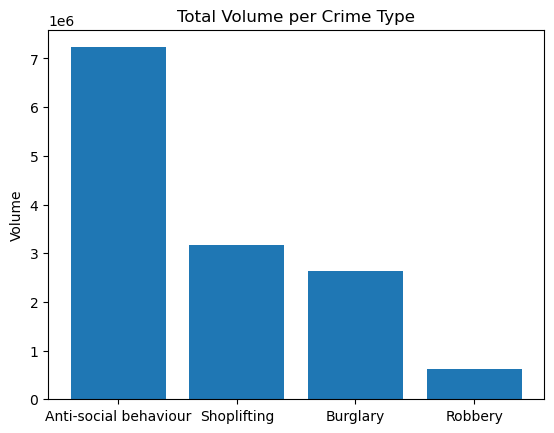

<Figure size 640x480 with 0 Axes>

In [8]:
plt.bar(crimeTypesInterested, crimeCounts)
plt.ylabel("Volume")
plt.title("Total Volume per Crime Type")
plt.show()
plt.savefig('volume.png', dpi=180, bbox_inches='tight', facecolor='white')

In [9]:
# now for the plot with harm
harm = [1, 5, 120, 365]

crimeHarms = [crimeCounts[i] * harm[i] for i in range(0, len(crimeTypesInterested))]
crimeHarms

[np.int64(7229856),
 np.int64(15884720),
 np.int64(316565760),
 np.int64(230424500)]

In [10]:
print(len(harm))
print(len(crimeTypesInterested))

4
4


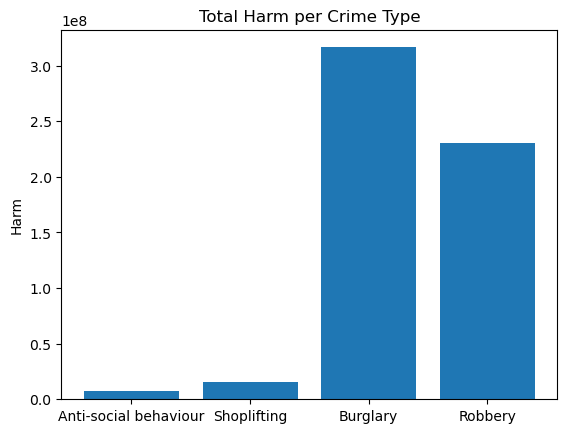

<Figure size 640x480 with 0 Axes>

In [11]:
plt.bar(crimeTypesInterested, crimeHarms)
plt.ylabel("Harm")
plt.title("Total Harm per Crime Type")
plt.show()
plt.savefig('harm.png', dpi=180, bbox_inches='tight', facecolor='white')

---

In [12]:
def get_crime_count(crime_type, area, timeColumn: str) -> list:
    '''
    Given an area and a crime type, the function returns a list of crime counts for each month given.
    '''
    filteredData = df[(df['LSOA name'] == area) & (df['Crime type'] == crime_type)]
    all_months = sorted(df[timeColumn].unique())
    crimeCount = filteredData[timeColumn].value_counts()
    crimeCount = crimeCount.reindex(all_months, fill_value=0)
    
    return list(crimeCount)


[14,
 23,
 20,
 17,
 24,
 22,
 33,
 25,
 28,
 16,
 5,
 15,
 8,
 7,
 11,
 18,
 28,
 45,
 26,
 39,
 35,
 20,
 9,
 16,
 16,
 17,
 40,
 30,
 24,
 23,
 39,
 20,
 25,
 12,
 8,
 20,
 16,
 15,
 5,
 8,
 22,
 29,
 44,
 47,
 37,
 27,
 7,
 3,
 1,
 7,
 15,
 12,
 10,
 17,
 17,
 33,
 26,
 16,
 6,
 10,
 1,
 10,
 11,
 16,
 4,
 6,
 8,
 8,
 7,
 12,
 7,
 3,
 10,
 11,
 12,
 16,
 18,
 7,
 22,
 10,
 19,
 10,
 14,
 18,
 11,
 10,
 13,
 11,
 15,
 15,
 11,
 14,
 19,
 10,
 7,
 3,
 13,
 5,
 9,
 8,
 12,
 15,
 27,
 14,
 13,
 12,
 9,
 6]

In [13]:
crime_counts_per_area = {
    crime_type : get_crime_count(crime_type, 'City of London 001B', 'Month') for crime_type in crimeTypes
}


In [14]:
region_df = df[df['LSOA name'].isin(['Metropolitan Police', 'City of London'])]

In [15]:
crimeDataFrame = (
    region_df
    .groupby(['Month', 'Crime type'])
    .size()                   
    .unstack(fill_value=0)       
    .sort_index()                  
)
crimeDataFrame = crimeDataFrame.reindex(columns=crimeTypes, fill_value=0)
crimeDataFrame.index.name = None
crimeDataFrame.columns.name = None

In [16]:
corrMatrix = crimeDataFrame.corr()

edge_list = corrMatrix.stack().reset_index()
edge_list.columns = ['Crime 1', 'Crime 2', 'Correlation']
strong_edges = edge_list[(edge_list['Correlation'] >= 0.3) & (edge_list['Correlation'] < 1.0)]


strong_edges = strong_edges.sort_values(by='Correlation', ascending=False)
print("Here are the strongest bridges:")
print(strong_edges)

Here are the strongest bridges:
Empty DataFrame
Columns: [Crime 1, Crime 2, Correlation]
Index: []


In [17]:
# Each row now contains the data from the previous month
shifted_df = crimeDataFrame.shift(1)

# Rename columns to keep track of the "Lead" and "Lag"
shifted_df.columns = [f"{c}_prevM" for c in crimeTypes]

# put them side-by-side and drop the first row because no data before month 1
combined_df = pd.concat([crimeDataFrame, shifted_df], axis=1).dropna()

# correlate the current month with the previous month
lagged_corr = combined_df.corr()

# Filter for correlations only current crimes and last month's crimes
# This finds if 'Theft_LastMonth' predicts 'Burglary' this month
lead_lag_edges = lagged_corr.loc[crimeTypes, [f"{c}_prevM" for c in crimeTypes]]

edgeList = lead_lag_edges.stack().reset_index()
edgeList.columns = ['Crime 1', 'Crime 2', 'Correlation']
strongEdges = edgeList[(edgeList['Correlation'] >= 0.3) & (edgeList['Correlation'] < 1.0)]


strongEdges = strongEdges.sort_values(by='Correlation', ascending=False)
print("Here are the strongest bridges:")
print(strongEdges.head(20))

Here are the strongest bridges:
Empty DataFrame
Columns: [Crime 1, Crime 2, Correlation]
Index: []


ValueError: max() iterable argument is empty

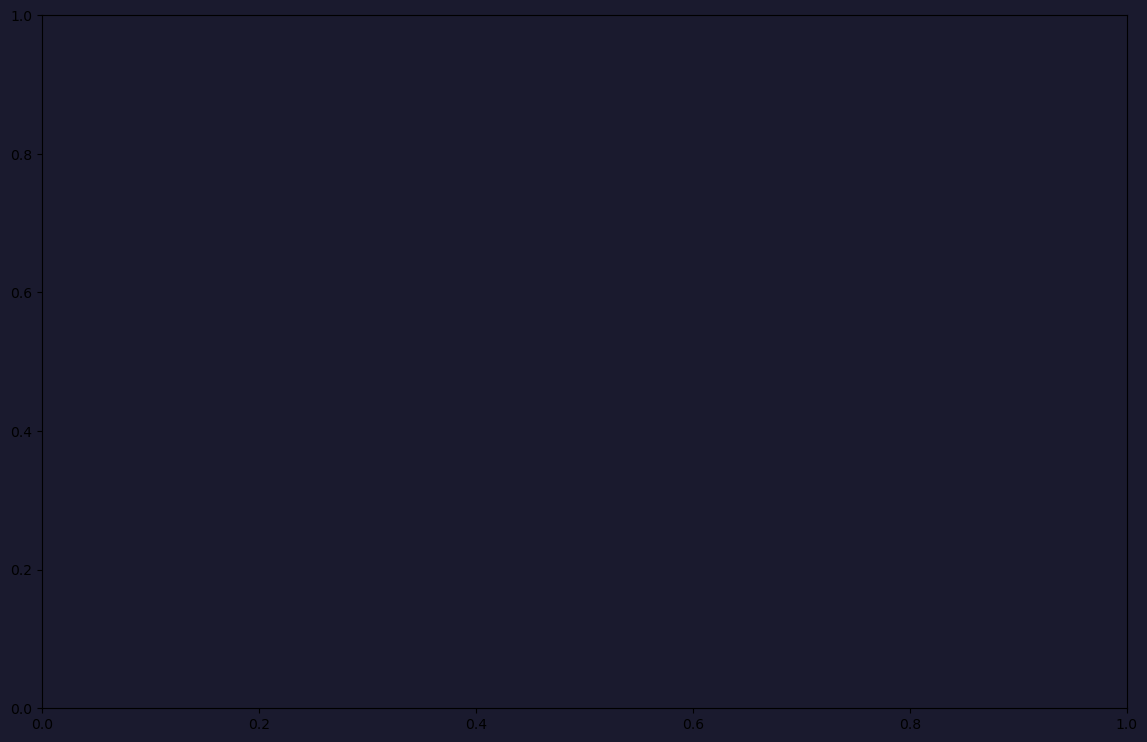

In [18]:
import networkx as nx
import matplotlib.cm as cm
import matplotlib.colors as mcolors

G = nx.DiGraph()
for index, row in strongEdges.iterrows():
    source_node = row['Crime 2'].replace('_prevM', '')
    target_node = row['Crime 1']
    weight = row['Correlation']
    # Skip self-loops - they add no information
    if source_node != target_node:
        G.add_edge(source_node, target_node, weight=weight)

centrality = nx.betweenness_centrality(G, weight='weight')

pos = nx.kamada_kawai_layout(G)

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

cmap = cm.plasma
norm = mcolors.Normalize(vmin=0, vmax=max(centrality.values()))
node_colours = [cmap(norm(centrality[n])) for n in G.nodes()]
node_sizes   = [centrality[n] * 8000 + 800 for n in G.nodes()]

edge_weights = [G[u][v]['weight'] * 4 for u, v in G.edges()]
nx.draw_networkx_edges(
    G, pos,
    width=edge_weights,
    arrowstyle='->',
    arrowsize=15,
    edge_color='#aaaaaa',
    alpha=0.5,
    ax=ax,
    connectionstyle='arc3,rad=0.1'
)

nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colours,
    alpha=0.95,
    ax=ax
)

for node, (x, y) in pos.items():
    # Push label away from origin
    dx = x - np.mean([p[0] for p in pos.values()])
    dy = y - np.mean([p[1] for p in pos.values()])
    norm_d = np.sqrt(dx**2 + dy**2) + 1e-6
    offset = 0.12
    ax.text(
        x + offset * dx / norm_d,
        y + offset * dy / norm_d,
        node,
        fontsize=9,
        fontweight='bold',
        color='white',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#1a1a2e', alpha=0.6, edgecolor='none')
    )

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Betweenness Centrality\n(Brokerage Score)', color='white', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

top3 = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:3]
for rank, (crime, score) in enumerate(top3):
    x, y = pos[crime]
    ax.annotate(
        f'#{rank+1} broker\n{score:.3f}',
        xy=(x, y),
        xytext=(x + 0.25, y + 0.15),
        color='#FFD700',
        fontsize=8,
        arrowprops=dict(arrowstyle='->', color='#FFD700', lw=1),
    )

ax.set_title(
    'Crime Ecosystem — Lagged Correlation Network (London LSOA)\n'
    'Node size & colour = brokerage score (betweenness centrality)  |  '
    'Edge weight = correlation strength  |  Edges filtered r > 0.3',
    color='white', fontsize=11, pad=15
)
ax.axis('off')
plt.tight_layout()
plt.savefig('crime_network.png', dpi=180, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()